In [31]:
import numpy as np
from numpy.typing import ArrayLike
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from datetime import datetime

# Toy 1: Sinusoidal data with Minimal AE

### Data

Let's say we have a simple sinusoidal data and a very simple autoencoder. Let's see if we can recover the data with the AE.

In [32]:
def sine(
    t_start: float = 0.,
    t_end: float = 20.,
    t_interval: float = 0.01,
    shift: float = 0.
):
    t_vals = np.linspace(
        start=t_start,
        stop=t_end,
        num=int((t_end-t_start)/t_interval),
        endpoint=False,
        dtype=np.float16)
    return t_vals, np.sin(t_vals-shift)

def plot_timeseries(
    x: ArrayLike,
    y: ArrayLike,
    xlabel: str,
    ylabel: str,
):
    plt.plot(x, y)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.axis('tight')
    plt.show()

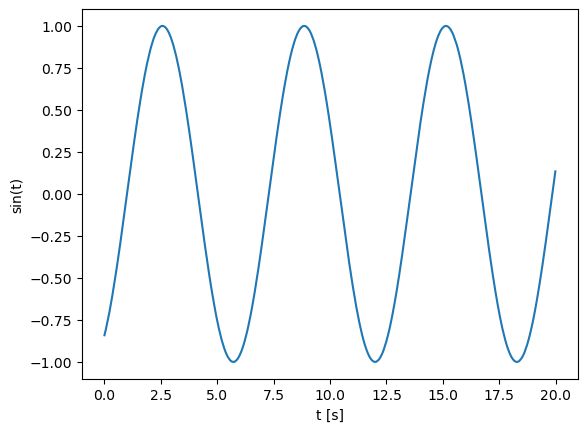

In [33]:
x, y = sine(shift=1)
plot_timeseries(x, y, 't [s]', 'sin(t)')

Having defined a function to generate one sample, we now need a good number of samples and a dataloader. The only variable that is randomly generated is the time shift.

In [34]:
def generate_sine_data(
    seq_start: float = 0.,
    seq_end: float = 30.,
    seq_interval: float = 0.01,
    num_samples: float = 1000
):
    t_vals = np.linspace(
        start=seq_start,
        stop=seq_end,
        num=int((seq_end-seq_start)/seq_interval),
        endpoint=False,
        dtype=np.float32
    )
    shift = np.random.uniform(
        low=0.0,
        high=2.0*np.pi,
        size=(num_samples, 1)
    ).astype(np.float32)
    
    sine_vals = np.sin(t_vals[None, :] - shift)

    return torch.from_numpy(sine_vals)

In [35]:
toy1_train_data = generate_sine_data(num_samples=800)
toy1_val_data = generate_sine_data(num_samples=100)
toy1_test_data = generate_sine_data(num_samples=100)

toy1_train_dataloader = DataLoader(toy1_train_data, batch_size=800, shuffle=True)
toy1_val_dataloader = DataLoader(toy1_val_data, batch_size=100, shuffle=True)
toy1_test_dataloader = DataLoader(toy1_test_data, batch_size=100, shuffle=True)

The model we use is a minimalistic autoencoder with only one hidden layer. We try both the MLP and the CNN methods.

In [36]:
class ToyAEMLP(nn.Module):
    # This is equivalent to PCA
    def __init__(
        self,
        seq_start: float = 0.,
        seq_end: float = 30.,
        seq_interval: float = 0.01,
        d_hidden: int = 100
    ):
        super().__init__()

        self.L = int((seq_end-seq_start)/seq_interval)
        self.D = d_hidden

        self.encoder = nn.Linear(self.L, self.D)
        # For non-linearity, introduce nn.ReLU() or the like
        self.decoder = nn.Linear(self.D, self.L)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, L]
        h = self.encoder(x)
        out = self.decoder(h)
        return out

class ToyAECNN(nn.Module):
    # This is equivalent to PCA
    def __init__(
        self,
        seq_start: float = 0.,
        seq_end: float = 30.,
        seq_interval: float = 0.01,
        latent_channels: int = 8,
        kernel_size: int = 5
    ):
        super().__init__()
        
        self.L = int((seq_end-seq_start)/seq_interval)
        p = kernel_size // 2

        # encoder: [B, 1, T] -> [B, C, T]
        self.encoder = nn.Conv1d(1, latent_channels, kernel_size, padding=p)
        # decoder: [B, C, T] -> [B, 1, T]
        self.decoder = nn.Conv1d(latent_channels, 1, kernel_size, padding=p)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, L]
        x = x.unsqueeze(1)  # Add channel dimension for Conv1d
        h = self.encoder(x)
        out = self.decoder(h)
        out = out.squeeze(1)  # Remove channel dimension
        return out

In [37]:
model_AEMLP = ToyAEMLP()
model_AECNN = ToyAECNN()

In [48]:
def train_one_epoch(
        model: nn.Module,
        train_loader: DataLoader,
        loss_fn: nn.Module,
        optimizer: torch.optim.Optimizer,
        verbose: bool = False
    ):
    running_loss = 0.

    for batch_idx, data in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(data)
        loss = loss_fn(outputs, data)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if verbose: print(f'  train/batch {batch_idx} train/loss: {loss}')

    return running_loss / (batch_idx + 1)

def val_one_epoch(
        model: nn.Module,
        val_loader: DataLoader,
        loss_fn: nn.Module,
        verbose: bool = False,
    ):
    running_vloss = 0.

    for batch_idx, vdata in enumerate(val_loader):
        outputs = model(vdata)
        vloss = loss_fn(outputs, vdata)
        running_vloss += vloss.item()
        if verbose: print(f'  val/batch {batch_idx} val/loss: {vloss}')

    return running_vloss / (batch_idx + 1)

def toy1_train(
        model: nn.Module,
        train_loader: DataLoader,
        val_loader: DataLoader,
        EPOCHS: int=100,
        verbose: bool=False
    ):
    timestamp = datetime.now().strftime('%Y%m%d%H%M%S')
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    best_vloss = 1_000_000.
    best_epoch = -1
    for epoch in range(EPOCHS):
        model.train(True)
        avg_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, verbose)

        model.train(False)
        avg_vloss = val_one_epoch(model, val_loader, loss_fn, verbose)
        if epoch % 10 == 0:
            print(
                f'##################### EPOCH {epoch} SUMMARY #####################\n' + 
                f'    train/loss: {avg_loss} | val/loss: {avg_vloss}\n'
            )

        if avg_vloss < best_vloss:
            best_vloss = avg_vloss
            best_epoch = epoch + 1

    if best_epoch != -1:
        model_path = f'{model.__class__.__name__}_{timestamp}_epoch{best_epoch}.pth'
        torch.save(model.state_dict(), model_path)
        print(f'Saved best model {model_path}.')
    return best_vloss

In [49]:
toy1_train(model_AEMLP, toy1_train_dataloader, toy1_val_dataloader, EPOCHS=1000)

##################### EPOCH 0 SUMMARY #####################
    train/loss: 2.841986315615941e-06 | val/loss: 0.5804441571235657

##################### EPOCH 10 SUMMARY #####################
    train/loss: 0.042571838945150375 | val/loss: 0.05255352705717087

##################### EPOCH 20 SUMMARY #####################
    train/loss: 0.013904538936913013 | val/loss: 0.012798299081623554

##################### EPOCH 30 SUMMARY #####################
    train/loss: 0.005300660151988268 | val/loss: 0.004754558205604553

##################### EPOCH 40 SUMMARY #####################
    train/loss: 0.0016639992827549577 | val/loss: 0.0016347997589036822

##################### EPOCH 50 SUMMARY #####################
    train/loss: 0.000542058318387717 | val/loss: 0.0004739286669064313

##################### EPOCH 60 SUMMARY #####################
    train/loss: 0.00022801486193202436 | val/loss: 0.00017980548727791756

##################### EPOCH 70 SUMMARY #####################
    train/l

1.3653563002424818e-10